<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/intelligence_system/IS_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade google-genai gradio requests pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.5/241.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.46.0
    Uninstalling google-genai-1.46.0:
      Successfully uninstalled google-genai-1.46.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [3]:
from getpass import getpass
import os

print("Paste keys when promped:")

GEMINI_KEY = getpass("Gemini API key: ")
os.environ["GEMINI_API_KEY"] = GEMINI_KEY
HF_KEY = getpass("HF_KEY:")
os.environ["HF_KEY"] = HF_KEY

Paste keys when promped:
Gemini API key: ··········
HF_KEY:··········


In [4]:
def call_hf_image(prompt):
    """
    Hugging Face Stable Diffusion XL example.
    """
    endpoint = "https://api-inference.huggingface.co/models/stabilityai/stable-diffusion-xl-base-1.0"
    headers = {"Authorization": f"Bearer {os.environ['HF_KEY']}"}
    payload = {"inputs": prompt}

    response = requests.post(endpoint, headers=headers, json=payload)
    if response.status_code != 200:
        return {"error": response.text}

    image_bytes = response.content
    from PIL import Image
    from io import BytesIO
    img = Image.open(BytesIO(image_bytes))
    return {"pil_image": img}

In [5]:
import google.generativeai as genai
import requests, json, time, base64, os
from PIL import Image
from io import BytesIO
from IPython.display import HTML, display

import sys
import matplotlib.pyplot as plt

# Initialize Genini client only if key provided
if os.environ.get('GEMINI_API_KEY'):

  """ Here the variable name is incorrect in the LAB doc then I fix the name here and put the name GEMINI_API_KEY
  """
  genai.configure(api_key=os.environ['GEMINI_API_KEY'])
  GEMINI_AVAILABLE = True
else:
    GEMINI_AVAILABLE = False
    print("Genini key not found - text generation disabled until you set GENINI_API_KEY.")

In [6]:
# Cell 5 - function: generate text with Gemini
def call_gemini(prompt):
    try:
      # I have use gemini-2.5 flash model to get the better result.
        model = genai.GenerativeModel("gemini-2.5-flash")
        response = model.generate_content(prompt)
        return {"type": "text", "content": response.text}
    except Exception as e:
        return {"type": "text", "content": f"Gemini error: {e}"}


In [7]:
def classify_intent(user_text):
  t = user_text.lower()
  # image tigger
  if "image" in t or "picture" in t or "photo" in t or t.startswith("Create me an image"):
    return "image"
  # text/generation/transform tiggers
  if any(k in t for k in ["write", "summarize", "explain", "draft", "describe", "generate text", "summarise"]):
    return "text"
  # fallback: if contains short multimeda instructions mention both -> prefer image
  if "create me" in t and "and" in t and ("video" in t or "image" in t):
    if "image" in t: return "image"
  # Default -> text
  return "text"


In [8]:
def handle_user_request(user_text):
    intent = classify_intent(user_text)
    print(f"[Agent] detected intent: {intent}")

    if intent == "text":
        return {"type": "text", "content": call_gemini(user_text)['content']}
    elif intent == "image":
        return {"type": "image", "content": call_hf_image(user_text)}
    else:
        return {"type": "text", "content": "Sorry, I don't understand."}

In [9]:
from PIL import Image
from IPython.display import display, HTML
import base64, io, requests, numpy as np
import time

def display_image_response(image_input, filename="/content/generated_image.png"):
    # Extract PIL Image
    if isinstance(image_input, dict):
        if 'pil_image' in image_input:
            img = image_input['pil_image']
        elif 'b64_json' in image_input:
            image_bytes = base64.b64decode(image_input['b64_json'])
            img = Image.open(io.BytesIO(image_bytes))
        elif 'url' in image_input:
            image_bytes = requests.get(image_input['url']).content
            img = Image.open(io.BytesIO(image_bytes))
        else:
            raise TypeError(f"Unsupported dict keys: {image_input.keys()}")
    elif isinstance(image_input, Image.Image):
        img = image_input
    elif isinstance(image_input, str):
        img = Image.open(image_input)
    elif isinstance(image_input, bytes):
        img = Image.open(io.BytesIO(image_input))
    elif isinstance(image_input, np.ndarray):
        img = Image.fromarray(image_input)
    else:
        raise TypeError(f"Unsupported image type: {type(image_input)}")

    # Save image
    img.save(filename)

    # Display thumbnail
    display(img.resize((256, 256)))
    time.sleep(2)


In [10]:
import textwrap

def pretty_print(text, width=80):
  print("\n".join(textwrap.wrap(text,width)))

Multimodal Agent (demo). Type 'exit' to quit.
You: Image of a single pink rose
[Agent] detected intent: image

Agent (image):


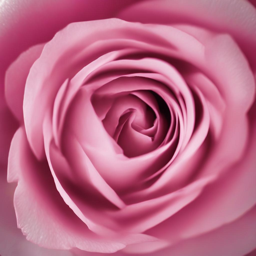

You: Write some description about agentic AI
[Agent] detected intent: text
Agentic AI refers to an artificial intelligence system that is designed to take
initiative, execute actions, and autonomously pursue a defined goal within an
environment. Unlike traditional AI models that primarily respond to direct
prompts or perform single tasks, agentic AI operates with a higher degree of
independence, planning, and execution.  Here's a breakdown of its key
characteristics and what makes it distinct:  1.  **Goal-Oriented:** It's given a
high-level objective (e.g., "Research market trends for sustainable packaging,"
"Book my travel for the conference in Berlin," "Develop a simple mobile app for
tracking habits"). Its entire operation is geared towards achieving this
ultimate goal.  2.  **Autonomous and Proactive:** Instead of waiting for step-
by-step instructions, an agentic AI initiates actions. It identifies what needs
to be done, breaks down the main goal into sub-tasks, and decides the se

In [11]:
print("Multimodal Agent (demo). Type 'exit' to quit.")

image_counter = 1  # optional: number images uniquely

while True:
    q = input("You: ")
    if q.strip().lower() in ("exit", "quit"):
        break

    out = handle_user_request(q)

    if out['type'] == 'text':
        print("\n", pretty_print(out['content']))
    elif out['type'] == 'image':
        print("\nAgent (image):")
        # Save with unique filename each time
        filename = f"generated_image_{image_counter}.png"
        display_image_response(out['content'], filename)
        image_counter += 1
    else:
        print("Unknown output type:", out.get('type'))

print("\n---\n")

## Learning Objecticve

In [12]:
# Google Gen AI SDK + utilities
!pip install --upgrade google-genai arxiv beautifulsoup4 requests readability-lxml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.7 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=aecd8bfc82082cf32dc07523329c906be9ec9c0af800400ac9ae89c6a7b2d869
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
  Attempting uninstall: beautifulsoup4
    Found existing installation: beautifulsoup4 4.13.5
    Uninstalling beautifulsoup4-4.13.5:
      Successfully uninstalled beautifulsoup4-4.13.5


In [25]:
from getpass import getpass
import os

api_key = getpass("Put your Gemini API key here: ")
os.environ["GEMINI_API_KEY"] = api_key

Put your Gemini API key here: ··········


## Initialize the Gen AI client in Colab.


In [26]:
from google import genai

# create a client using the key that we provided
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [27]:
# I try to use gemini-2.5-flash model to get better and refined response instead of gemini-1.5-flash
resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents = "Summarize in the one sentence: Why reproducibility important in research?"
)
print(resp.text)

Reproducibility is crucial because it confirms the validity and reliability of research findings, thereby building trust and enabling robust scientific advancement.


In [28]:
import arxiv

def search_arxiv(query, max_results=5):
    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance
    )
    results = []
    for result in search.results():
        results.append({
            "title": result.title,
            "summary": result.summary,
            "authors": [a.name for a in result.authors],
            "pdf_url": result.pdf_url,
            "id": result.get_short_id()
        })
    return results

# quick test
papers = search_arxiv("multimodal transformers", max_results=3)
for p in papers:
    print(p['title'])

/tmp/ipython-input-2133896698.py:10: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for result in search.results():


Multimodal Learning with Transformers: A Survey
MANGO: Multimodal Attention-based Normalizing Flow Approach to Fusion Learning
Multimodal Transformer With a Low-Computational-Cost Guarantee


**Grab web-page content for non-paper websites**

In [30]:
import requests
from bs4 import BeautifulSoup

def fetch_page_text(url, max_chars=4000):
    try:
        r = requests.get(url, timeout=10, headers={"User-Agent":"research-agent/1.0"})
        r.raise_for_status()
    except Exception as e:
        return ""
    soup = BeautifulSoup(r.text, "html.parser")
    # simple extraction: join visible <p> text
    paragraphs = [p.get_text(separator=" ", strip=True) for p in soup.find_all("p")]
    content = "\n\n".join(paragraphs)
    return content[:max_chars] # limit length for API

**Summarization: chunking + calling Gemini**

In [31]:
def chunk_text(text, max_chars=3000):
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + max_chars)
        chunks.append(text[start:end])
        start += max_chars
    return chunks

**Create a function that asks Gemini to summarize a text chunk**


In [36]:
SYSTEM_PROMPT = (
    "You are a concise research assistant. For each text provided, return: "
    "1) a one-paragraph summary (3-5 sentences), 2) three bullet key contributions/findings, "
    "and 3) a suggested short title. Be factual and include no hallucinated facts."
)

def summarize_chunk(chunk_text):
    prompt = SYSTEM_PROMPT + "\n\nText to summarize:\n" + chunk_text
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    return resp.text

In [37]:
def summarize_text_long(text):
    chunks = chunk_text(text, max_chars=3000)
    summaries = []
    for c in chunks:
        s = summarize_chunk(c)
        summaries.append(s)
    # Optionally aggregate the chunk summaries into a single final summary:
    if len(summaries) == 1:
        return summaries[0]
    else:
        combined = "\n\n".join(summaries)
        final_prompt = SYSTEM_PROMPT + "\n\nCombine the following chunk summaries into a single concise summary:\n\n" + combined
        final_resp = client.models.generate_content(model="gemini-2.5-flash", contents=final_prompt)
        return final_resp.text

**Example: search arXiv + summarize abstracts**

In [38]:
query = "multimodal transformers"
papers = search_arxiv(query, max_results=5)

for p in papers:
    print("\n---")
    print("Title:", p['title'])
    text_to_summarize = p['summary']  # arXiv abstract (short)
    summary = summarize_text_long(text_to_summarize)
    print("Summary:\n", summary)
    print("PDF:", p['pdf_url'])

/tmp/ipython-input-2133896698.py:10: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for result in search.results():



---
Title: Multimodal Learning with Transformers: A Survey
Summary:
 1.  **One-paragraph summary:**
    This paper offers a comprehensive survey of Transformer techniques specifically oriented towards multimodal data, an increasingly significant area in AI research. The survey provides background on multimodal learning, the Transformer ecosystem, and the multimodal big data era. It includes a theoretical review of various Transformer architectures—Vanilla, Vision, and multimodal Transformers—from a geometrically topological perspective. Furthermore, the paper examines multimodal Transformer applications across pretraining and specific tasks, summarizing common challenges and design principles. Finally, it discusses open problems and potential future research directions within the field.

2.  **Three bullet key contributions/findings:**
    *   Presents a comprehensive survey of Transformer techniques tailored for multimodal data, emphasizing its growing importance in AI.
    *   Provi

**Save results (Drive)**

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
# Output result will appear in the from ot txt file format
out_path = "/content/drive/MyDrive/intelligent_system/research_summaries.txt"
with open(out_path, 'w', encoding='utf-8') as f:
    for p in papers:
        f.write("TITLE: " + p['title'] + "\n")
        s = summarize_text_long(p['summary'])
        f.write(s + "\n\n--\n")
print("Saved to", out_path)

Saved to /content/drive/MyDrive/intelligent_system/research_summaries.txt
